In [4]:
import pandas as pd
import numpy as np

data_path = r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_europe.csv'
returns_eu = pd.read_csv(data_path, index_col=0, parse_dates=True)

ticker = 'ASML.AS'
r_asml = returns_eu[ticker].dropna()

mu_real = r_asml.mean() * 252
sigma_real = r_asml.std() * np.sqrt(252)

print(f"Ticker: {ticker}")
print(f"mu (annualizzato):    {mu_real:.4f} ({mu_real:.2%})")
print(f"sigma (annualizzata): {sigma_real:.4f} ({sigma_real:.2%})")
print(f"Osservazioni:         {len(r_asml)}")

Ticker: ASML.AS
mu (annualizzato):    0.2753 (27.53%)
sigma (annualizzata): 0.3326 (33.26%)
Osservazioni:         2824


In [2]:
import os
os.makedirs('../results', exist_ok=True)

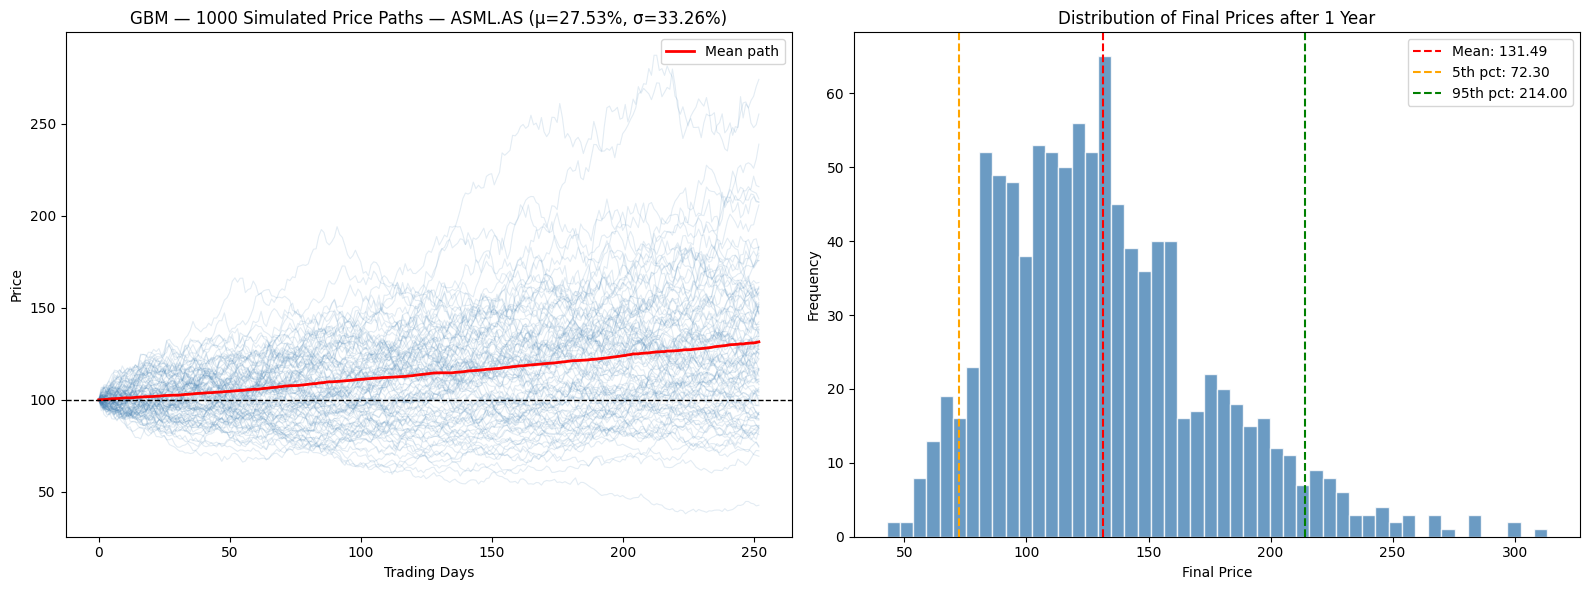

Mean final price: 131.49
Std final price:  43.62
5th percentile:   72.30
95th percentile:  214.00


In [5]:
# Cella 1 - Geometric Brownian Motion
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parametri reali stimati da dati storici ASML.AS (2015-2026)
S0 = 100
mu = 0.2753
sigma = 0.3326
T = 1.0
dt = 1/252
N = 252
M = 1000

np.random.seed(42)

# Simulazione GBM
Z = np.random.standard_normal((M, N))
daily_returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

# Costruisci i path
paths = np.ones((M, N + 1))
paths[:, 0] = S0
for t in range(1, N + 1):
    paths[:, t] = paths[:, t-1] * daily_returns[:, t-1]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Path simulati
axes[0].plot(paths[:100].T, alpha=0.15, linewidth=0.8, color='steelblue')
axes[0].plot(paths.mean(axis=0), color='red', linewidth=2, label='Mean path')
axes[0].axhline(y=S0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'GBM — {M} Simulated Price Paths — ASML.AS (μ={mu:.2%}, σ={sigma:.2%})', fontsize=12)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Price')
axes[0].legend()

# Distribuzione prezzi finali
final_prices = paths[:, -1]
axes[1].hist(final_prices, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=final_prices.mean(), color='red', linestyle='--', label=f'Mean: {final_prices.mean():.2f}')
axes[1].axvline(x=np.percentile(final_prices, 5), color='orange', linestyle='--', label=f'5th pct: {np.percentile(final_prices, 5):.2f}')
axes[1].axvline(x=np.percentile(final_prices, 95), color='green', linestyle='--', label=f'95th pct: {np.percentile(final_prices, 95):.2f}')
axes[1].set_title('Distribution of Final Prices after 1 Year', fontsize=12)
axes[1].set_xlabel('Final Price')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/gbm_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean final price: {final_prices.mean():.2f}")
print(f"Std final price:  {final_prices.std():.2f}")
print(f"5th percentile:   {np.percentile(final_prices, 5):.2f}")
print(f"95th percentile:  {np.percentile(final_prices, 95):.2f}")

Monte Carlo price:       10.9621
95% Confidence Interval: (10.8260, 11.0982)
Black-Scholes price:     10.9257
Difference:              0.0364


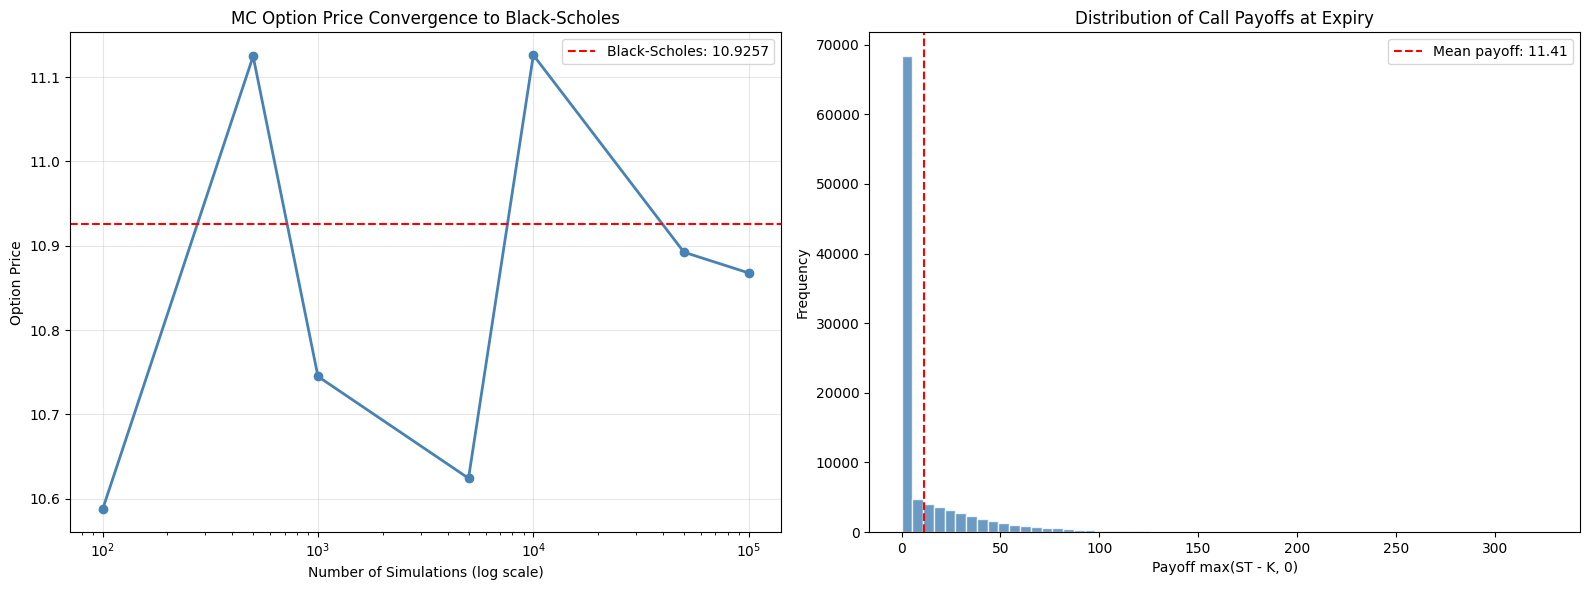

In [6]:
# Cella 2 — European Call Option Pricing via Monte Carlo

from scipy.stats import norm

S0 = 100
K = 110        # leggermente out of the money
r = 0.04
sigma = 0.3326
T = 1.0
M = 100000

np.random.seed(42)

# Simulazione risk-neutral (sostituiamo mu con r)
Z = np.random.standard_normal(M)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Payoff call europea: max(ST - K, 0)
payoffs = np.maximum(ST - K, 0)
mc_price = np.exp(-r * T) * payoffs.mean()
mc_std = np.exp(-r * T) * payoffs.std() / np.sqrt(M)
mc_ci = (mc_price - 1.96 * mc_std, mc_price + 1.96 * mc_std)

# Prezzo analitico Black-Scholes per confronto
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"Monte Carlo price:       {mc_price:.4f}")
print(f"95% Confidence Interval: ({mc_ci[0]:.4f}, {mc_ci[1]:.4f})")
print(f"Black-Scholes price:     {bs_price:.4f}")
print(f"Difference:              {abs(mc_price - bs_price):.4f}")

# Convergenza del prezzo MC al crescere delle simulazioni
sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []

for n in sizes:
    Z_n = np.random.standard_normal(n)
    ST_n = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_n)
    payoff_n = np.maximum(ST_n - K, 0)
    mc_prices.append(np.exp(-r * T) * payoff_n.mean())

# Plot convergenza
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].semilogx(sizes, mc_prices, 'o-', color='steelblue', linewidth=2, markersize=6)
axes[0].axhline(y=bs_price, color='red', linestyle='--', linewidth=1.5, label=f'Black-Scholes: {bs_price:.4f}')
axes[0].set_title('MC Option Price Convergence to Black-Scholes', fontsize=12)
axes[0].set_xlabel('Number of Simulations (log scale)')
axes[0].set_ylabel('Option Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuzione payoff
axes[1].hist(payoffs, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(x=payoffs.mean(), color='red', linestyle='--', label=f'Mean payoff: {payoffs.mean():.2f}')
axes[1].set_title('Distribution of Call Payoffs at Expiry', fontsize=12)
axes[1].set_xlabel('Payoff max(ST - K, 0)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/mc_option_pricing.png', dpi=150, bbox_inches='tight')
plt.show()